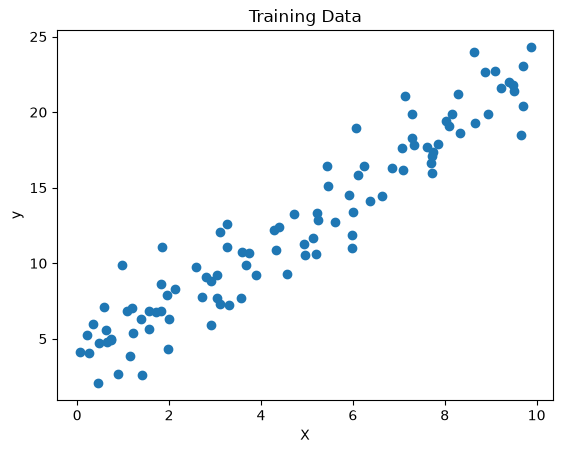

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# generate random data for linear regression
X = np.random.rand(100, 1) * 10
y = 2*X + 3 + np.random.randn(100, 1) * 2

# plot the training data
plt.scatter(X, y)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Training Data')
plt.show()

In [16]:
def cost_func_linear(X, y, theta):
    X_b = np.c_[np.ones((len(X), 1)), X] # add bias term
    Y_pred = np.matmul(X_b, theta) # predicted values
    m = len(y) # number of training examples
    mse = 1/(2*m) * np.sum((Y_pred - y)**2) # mean squared error
    return mse

In [17]:
theta = np.zeros((2, 1))
print(cost_func_linear(X, y, theta))

94.4599134069454


In [18]:
def gradient_descent_linear(X, y, theta, learning_rate, iterations):
    m = len(y)
    X_b = np.c_[np.ones((len(X), 1)), X]
    cost_history = [] # for storing cost at each iteration

    for i in range(iterations):
        Y_pred = np.matmul(X_b, theta)
        theta = theta - learning_rate * (1/m) * np.matmul(X_b.T, (Y_pred-y)) # update theta in each iteration
        cost_history.append(cost_func_linear(X, y, theta))

    return theta, cost_history

In [19]:

theta = np.zeros((2, 1))
theta, cost_history = gradient_descent_linear(X, y, theta, learning_rate=0.01, iterations=1000)
print(theta)

[[3.23955053]
 [1.93734667]]


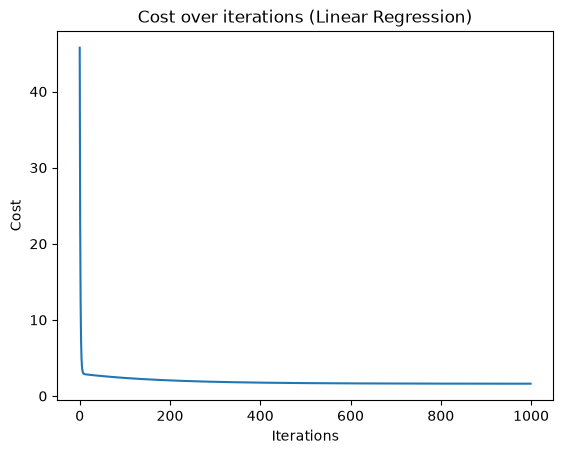

In [20]:
plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("Cost over iterations (Linear Regression)")
plt.show()

In [21]:
def stochastic_gradient_descent(X, y, theta, learning_rate, iterations):
    m = len(y)
    X_b = np.c_[np.ones((len(X), 1)), X]
    cost_history = [] # for storing cost at each iteration

    for i in range(iterations):
        ind = np.random.randint(0, m) # randomly select an index
        X_i = X_b[ind:ind+1] # select the corresponding row of X_b - one sample
        y_i = y[ind:ind+1] # select the corresponding row of y - one sample
        Y_pred = np.matmul(X_i, theta)
        theta = theta - learning_rate * np.matmul(X_i.T, (Y_pred-y_i)) # update theta in each iteration
        cost_history.append(cost_func_linear(X, y, theta))

    return theta, cost_history

[[3.41546947]
 [1.83962436]]


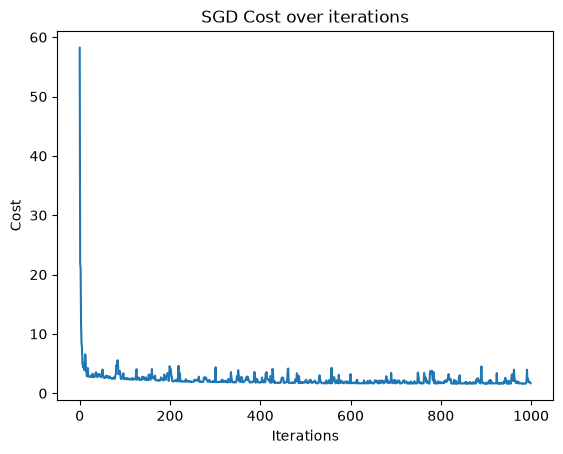

In [22]:
theta = np.zeros((2, 1))
theta, cost_history = stochastic_gradient_descent(X, y, theta, learning_rate=0.01, iterations=1000)
print(theta)

plt.plot(cost_history)
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.title("SGD Cost over iterations")
plt.show()

In [23]:
def normal_equation(X, y):
    X_b = np.c_[np.ones((len(X), 1)), X]
    A = np.linalg.inv(np.matmul(X_b.T, X_b)) # getting inverse of X_b.T * X_b
    B = np.matmul(X_b.T, y)
    theta = np.matmul(A, B)
    return theta

In [24]:
theta = normal_equation(X, y)
print(theta)

[[3.43019232]
 [1.90804535]]
